In [123]:
import numpy as np
import pandas as pd
import json
import io
import math
from abc import abstractmethod
from collections import deque
from typing import List, Tuple, Dict
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState
from enum import IntEnum
from statistics import NormalDist
from typing import Any, TypeAlias
from collections import defaultdict
import matplotlib.pyplot as plt
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
# import ace_tools as tools

JSON: TypeAlias = dict[str, "JSON"] | list["JSON"] | str | int | float | bool | None

In [124]:
product = 'RAINFOREST_RESIN'
position_product = 'position_RAINFOREST_RESIN'

product = 'KELP'
position_product = 'position_KELP'

product = 'SQUID_INK'
position_product = 'position_SQUID_INK'

In [125]:
def _process_data_(file):
    with open(file, 'r') as file:
        log_content = file.read()
    sections = log_content.split('Sandbox logs:')[1].split('Activities log:')
    my_data = sections[0].strip()
    sandbox_log =  sections[0].strip()
    activities_log = sections[1].split('Trade History:')[0]
    # sandbox_log_list = [json.loads(line) for line in sandbox_log.split('\n')]
    trade_history =  json.loads(sections[1].split('Trade History:')[1])
    # sandbox_log_df = pd.DataFrame(sandbox_log_list)
    market_data_df = pd.read_csv(io.StringIO(activities_log), sep=";", header=0)
    trade_history_df = pd.json_normalize(trade_history)
    return market_data_df, trade_history_df, my_data

market_data, trade_history, my_data = _process_data_('r1.log')

In [126]:
import json
import re
import pandas as pd

# 提取 JSON 块
json_blocks = re.findall(r'{[^{}]*"timestamp"\s*:\s*\d+\s*}', my_data)

# 转成字典列表
parsed = [json.loads(block) for block in json_blocks]

records = []

for block in parsed:
    timestamp = block.get("timestamp")
    lambda_log = block.get("lambdaLog", "")

    for line in lambda_log.strip().splitlines():
        order_match = re.match(r'\[(.*?)\] (\w+) → (BUY|SELL) (\d+) @ (\d+)', line)
        if order_match:
            symbol, action_type, side, qty, price = order_match.groups()
            records.append({
                "timestamp": timestamp,
                "symbol": symbol,
                "action_type": action_type,
                "side": side,
                "quantity": int(qty),
                "price": int(price)
            })

# 创建 DataFrame
df = pd.DataFrame(records)

In [127]:
df[df['action_type'] == 'TAKE']

,timestamp,symbol,action_type,side,quantity,price
8,100,RAINFOREST_RESIN,TAKE,SELL,1,10002
57,900,RAINFOREST_RESIN,TAKE,BUY,11,9998
82,1300,RAINFOREST_RESIN,TAKE,SELL,1,10002
95,1500,RAINFOREST_RESIN,TAKE,BUY,4,9998
138,2200,RAINFOREST_RESIN,TAKE,BUY,4,9998
...,...,...,...,...,...,...
5949,97900,RAINFOREST_RESIN,TAKE,SELL,3,10002
5974,98300,RAINFOREST_RESIN,TAKE,BUY,1,9998
5987,98500,RAINFOREST_RESIN,TAKE,BUY,1,9998
6036,99300,RAINFOREST_RESIN,TAKE,BUY,1,9998


In [128]:
def robust_extract_logs(data):
    json_blocks = re.findall(r'\{[\s\S]*?"timestamp"[\s\S]*?\}', data)
    extracted_data = []
    for block in json_blocks:
        timestamp_match = re.search(r'"timestamp"\s*:\s*(\d+)', block)
        timestamp = int(timestamp_match.group(1)) if timestamp_match else None
        # position = int(position_match.group(1)) if position_match else None
        segments = re.findall(r'startstart([\s\S]*?)endend', block)
        position = re.findall(r'position(-?\d+)', block)
        if timestamp is not None and len(segments) > 0:
            extracted_data.append({
                'timestamp': timestamp,
                'KELP': segments[0].strip(),
                'RAINFOREST_RESIN': segments[1].strip(),
                'SQUID_INK': segments[2].strip(),
                'position_KELP': int(position[0].strip()),
                'position_RAINFOREST_RESIN': int(position[1].strip()),
                'position_SQUID_INK': int(position[2].strip()),
            })
    return pd.DataFrame(extracted_data)

extracted_df = robust_extract_logs(my_data)

def extract_info(segment, timestamp):
    buy_matches = re.findall(r'buy\((\d+),\s*(\d+)\)', segment)
    sell_matches = re.findall(r'sell\((\d+),\s*(\d+)\)', segment)
    buy = []
    sell = []
    for price, volume in buy_matches:
        buy.append({
            'timestamp': timestamp,
            'price': int(price),
            'volume': int(volume)
        })
    for price, volume in sell_matches:
        sell.append({
            'timestamp': timestamp,
            'price': int(price),
            'volume': int(volume)
        })
    return buy, sell

buy_data = []
sell_data = []
for _, row in extracted_df.iterrows():
    timestamp = row['timestamp']
    buy_data += extract_info(row[product], timestamp)[0]
    sell_data += extract_info(row[product], timestamp)[1]
buy_df = pd.DataFrame(buy_data)
sell_df = pd.DataFrame(sell_data)


In [129]:
extracted_df

,timestamp,KELP,RAINFOREST_RESIN,SQUID_INK,position_KELP,position_RAINFOREST_RESIN,position_SQUID_INK
0,0,\nto_buy50...\nto_sell50...\nposition0...\n[KE...,\nto_buy50...\nto_sell50...\nposition0...\n[RA...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,0,0,0
1,100,\nto_buy50...\nto_sell50...\nposition0...\n[KE...,\nto_buy50...\nto_sell50...\nposition0...\n[RA...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,0,0,0
2,200,\nto_buy51...\nto_sell49...\nposition-1...\n[K...,\nto_buy51...\nto_sell49...\nposition-1...\n[R...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,-1,-1,0
3,300,\nto_buy52...\nto_sell48...\nposition-2...\n[K...,\nto_buy52...\nto_sell48...\nposition-2...\n[R...,\nto_buy51...\nto_sell49...\nposition-1...\n[S...,-2,-2,-1
4,400,\nto_buy53...\nto_sell47...\nposition-3...\n[K...,\nto_buy52...\nto_sell48...\nposition-2...\n[R...,\nto_buy52...\nto_sell48...\nposition-2...\n[S...,-3,-2,-2
...,...,...,...,...,...,...,...
995,99500,\nto_buy21...\nto_sell79...\nposition29...\n[K...,\nto_buy30...\nto_sell70...\nposition20...\n[R...,\nto_buy19...\nto_sell81...\nposition31...\n[S...,29,20,31
996,99600,\nto_buy21...\nto_sell79...\nposition29...\n[K...,\nto_buy27...\nto_sell73...\nposition23...\n[R...,\nto_buy19...\nto_sell81...\nposition31...\n[S...,29,23,31
997,99700,\nto_buy33...\nto_sell67...\nposition17...\n[K...,\nto_buy27...\nto_sell73...\nposition23...\n[R...,\nto_buy31...\nto_sell69...\nposition19...\n[S...,17,23,19
998,99800,\nto_buy31...\nto_sell69...\nposition19...\n[K...,\nto_buy25...\nto_sell75...\nposition25...\n[R...,\nto_buy29...\nto_sell71...\nposition21...\n[S...,19,25,21


In [130]:
extracted_df

,timestamp,KELP,RAINFOREST_RESIN,SQUID_INK,position_KELP,position_RAINFOREST_RESIN,position_SQUID_INK
0,0,\nto_buy50...\nto_sell50...\nposition0...\n[KE...,\nto_buy50...\nto_sell50...\nposition0...\n[RA...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,0,0,0
1,100,\nto_buy50...\nto_sell50...\nposition0...\n[KE...,\nto_buy50...\nto_sell50...\nposition0...\n[RA...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,0,0,0
2,200,\nto_buy51...\nto_sell49...\nposition-1...\n[K...,\nto_buy51...\nto_sell49...\nposition-1...\n[R...,\nto_buy50...\nto_sell50...\nposition0...\n[SQ...,-1,-1,0
3,300,\nto_buy52...\nto_sell48...\nposition-2...\n[K...,\nto_buy52...\nto_sell48...\nposition-2...\n[R...,\nto_buy51...\nto_sell49...\nposition-1...\n[S...,-2,-2,-1
4,400,\nto_buy53...\nto_sell47...\nposition-3...\n[K...,\nto_buy52...\nto_sell48...\nposition-2...\n[R...,\nto_buy52...\nto_sell48...\nposition-2...\n[S...,-3,-2,-2
...,...,...,...,...,...,...,...
995,99500,\nto_buy21...\nto_sell79...\nposition29...\n[K...,\nto_buy30...\nto_sell70...\nposition20...\n[R...,\nto_buy19...\nto_sell81...\nposition31...\n[S...,29,20,31
996,99600,\nto_buy21...\nto_sell79...\nposition29...\n[K...,\nto_buy27...\nto_sell73...\nposition23...\n[R...,\nto_buy19...\nto_sell81...\nposition31...\n[S...,29,23,31
997,99700,\nto_buy33...\nto_sell67...\nposition17...\n[K...,\nto_buy27...\nto_sell73...\nposition23...\n[R...,\nto_buy31...\nto_sell69...\nposition19...\n[S...,17,23,19
998,99800,\nto_buy31...\nto_sell69...\nposition19...\n[K...,\nto_buy25...\nto_sell75...\nposition25...\n[R...,\nto_buy29...\nto_sell71...\nposition21...\n[S...,19,25,21


In [131]:
df = trade_history[trade_history['symbol']==product]

<Axes: >

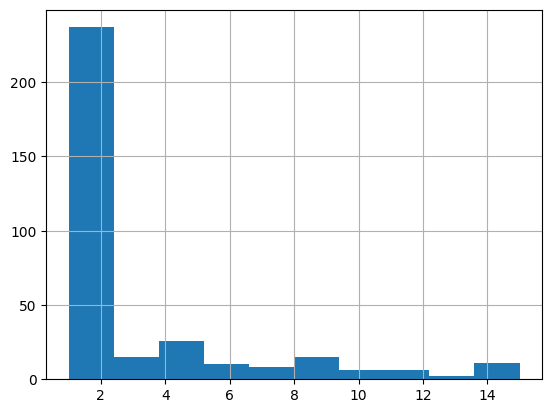

In [132]:
df['quantity'].hist()

In [133]:
market_orders = trade_history[(trade_history['buyer']!="SUBMISSION") & (trade_history['seller']!="SUBMISSION") & (trade_history['symbol']==product)]
buy_order = trade_history[(trade_history['buyer']=="SUBMISSION") & (trade_history['symbol']== product)]
sell_order = trade_history[(trade_history['seller']=="SUBMISSION") & (trade_history['symbol']==product)]
market = market_data[market_data['product']==product]

market_orders.loc[:, 'timestamp'] /= 100
buy_order.loc[:, 'timestamp'] /= 100
sell_order.loc[:, 'timestamp'] /= 100
market.loc[:, 'timestamp'] /= 100
# buy_df.loc[:, 'timestamp'] /= 100
# sell_df.loc[:, 'timestamp'] /= 100

<Axes: >

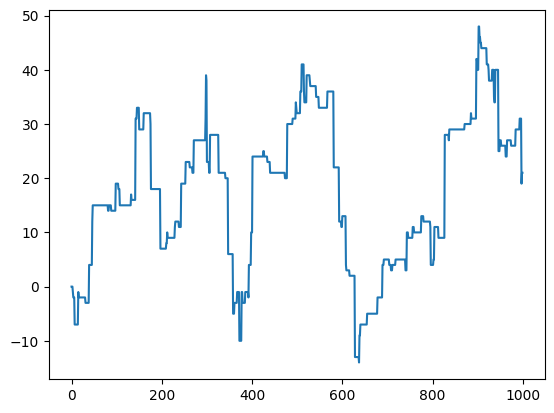

In [134]:
extracted_df[position_product].plot()

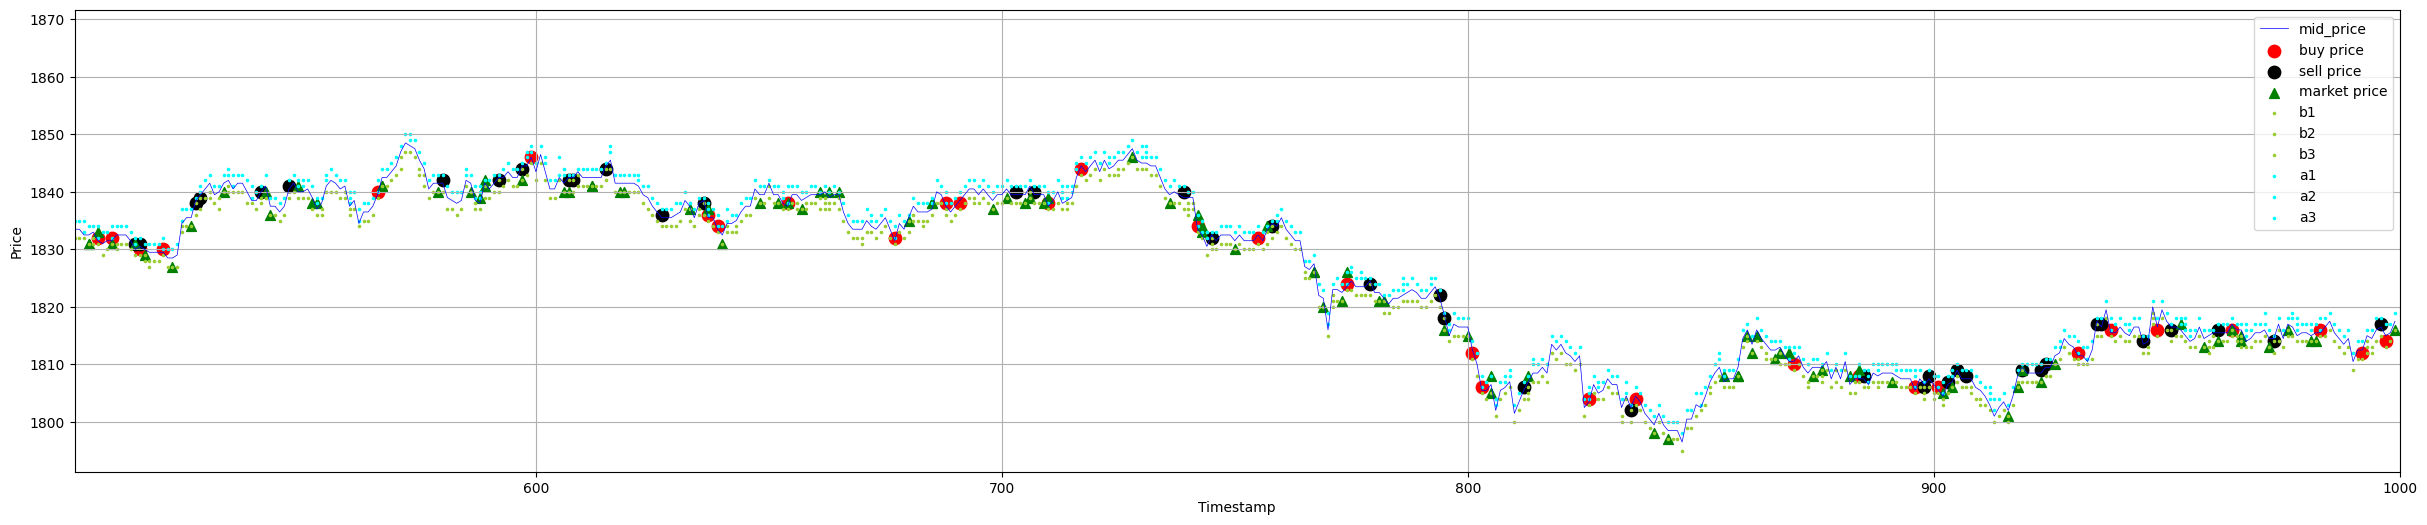

In [135]:
plt.figure(figsize=(30, 6))

plt.plot(market['timestamp'], market['mid_price'], label='mid_price', color='blue', linewidth=0.5)

plt.scatter(buy_order['timestamp'], buy_order['price'], label='buy price', color='red', s=80, marker='o')
plt.scatter(sell_order['timestamp'], sell_order['price'], label='sell price', color='black', s=80, marker='o')

plt.scatter(market_orders['timestamp'], market_orders['price'], label='market price', color='green', s=50, marker='^')

# plt.scatter(buy_df['timestamp'], buy_df['price'], label='buy LO', color='orange', s=40, marker='.')
# plt.scatter(sell_df['timestamp'], sell_df['price'], label='sell LO', color='green', s=40, marker='.')

plt.scatter(market['timestamp'], market['bid_price_1'], label='b1', color='yellowgreen', s=10, marker='.')
plt.scatter(market['timestamp'], market['bid_price_2'], label='b2', color='yellowgreen', s=10, marker='.')
plt.scatter(market['timestamp'], market['bid_price_3'], label='b3', color='yellowgreen', s=10, marker='.')

plt.scatter(market['timestamp'], market['ask_price_1'], label='a1', color='cyan', s=10, marker='.')
plt.scatter(market['timestamp'], market['ask_price_2'], label='a2', color='cyan', s=10, marker='.')
plt.scatter(market['timestamp'], market['ask_price_3'], label='a3', color='cyan', s=10, marker='.')

plt.xlabel('Timestamp')
plt.ylabel('Price')
# plt.gca().yaxis.set_major_locator(MultipleLocator(1)) # 间隔设为1，只显示整数
plt.legend()
plt.grid(True)
plt.xlim(501, 1000)
plt.show()

In [136]:
sell = trade_history[(trade_history['symbol'] == product) &(trade_history['seller'] == 'SUBMISSION') ]
buy = trade_history[(trade_history['symbol'] == product) &(trade_history['buyer'] == 'SUBMISSION') ]

# s1 = int(sum(sell['price']*sell['quantity'])-sum(buy['price']*buy['quantity']) + extracted_df.loc[1999,position_product]*10000)


In [137]:
trade_history[(trade_history['symbol'] == product)]

,timestamp,buyer,seller,symbol,currency,price,quantity
4,200,,SUBMISSION,SQUID_INK,SEASHELLS,1834,1
6,300,,SUBMISSION,SQUID_INK,SEASHELLS,1836,1
8,500,,,SQUID_INK,SEASHELLS,1836,1
10,600,,SUBMISSION,SQUID_INK,SEASHELLS,1834,5
12,600,,,SQUID_INK,SEASHELLS,1832,14
...,...,...,...,...,...,...,...
1042,98300,SUBMISSION,,SQUID_INK,SEASHELLS,1816,3
1049,99200,SUBMISSION,,SQUID_INK,SEASHELLS,1812,2
1054,99600,,SUBMISSION,SQUID_INK,SEASHELLS,1817,12
1057,99700,SUBMISSION,,SQUID_INK,SEASHELLS,1814,2


In [138]:
df = trade_history[(trade_history['symbol'] == product)].reset_index(drop=True)

for i in range(len(df.index)):
    if df.loc[i,'seller'] == 'SUBMISSION':
        df.loc[i,'pnl'] = df.loc[i,'price']*df.loc[i,'quantity']
    elif df.loc[i,'buyer'] == 'SUBMISSION':
        df.loc[i,'pnl'] = -df.loc[i,'price']*df.loc[i,'quantity']
df['total'] = df['pnl'].cumsum()

df
    

,timestamp,buyer,seller,symbol,currency,price,quantity,pnl,total
0,200,,SUBMISSION,SQUID_INK,SEASHELLS,1834,1,1834.0,1834.0
1,300,,SUBMISSION,SQUID_INK,SEASHELLS,1836,1,1836.0,3670.0
2,500,,,SQUID_INK,SEASHELLS,1836,1,NaN,NaN
3,600,,SUBMISSION,SQUID_INK,SEASHELLS,1834,5,9170.0,12840.0
4,600,,,SQUID_INK,SEASHELLS,1832,14,NaN,NaN
...,...,...,...,...,...,...,...,...,...
331,98300,SUBMISSION,,SQUID_INK,SEASHELLS,1816,3,-5448.0,-52980.0
332,99200,SUBMISSION,,SQUID_INK,SEASHELLS,1812,2,-3624.0,-56604.0
333,99600,,SUBMISSION,SQUID_INK,SEASHELLS,1817,12,21804.0,-34800.0
334,99700,SUBMISSION,,SQUID_INK,SEASHELLS,1814,2,-3628.0,-38428.0


In [139]:
product = "STARFRUIT"

market_ = trade_history[(trade_history['symbol'] == product) &(trade_history['seller'] != 'SUBMISSION')&(trade_history['buyer'] != 'SUBMISSION') ]
market_.head(30)

,timestamp,buyer,seller,symbol,currency,price,quantity


In [140]:
def weighted_avg_price(prices, volumes):
    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    if mask.sum() == 0:
        return np.nan
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# 计算加权买价（前三档）
market_data['weighted_bid'] = market_data.apply(lambda row: weighted_avg_price(
    np.array([row['bid_price_1'], row['bid_price_2'], row['bid_price_3']]),
    np.array([row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']])
), axis=1)

In [141]:
df = market_data[market_data['product'] == 'STARFRUIT']
def weighted_avg_price(prices, volumes):
    prices = np.array(prices, dtype=np.float64)
    volumes = np.array(volumes, dtype=np.float64)
    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    
    if np.sum(volumes[mask]) == 0:
        return np.nan
    
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# 假设你的 DataFrame 是 df
df['weighted_bid'] = df.apply(lambda row: weighted_avg_price(
    [row['bid_price_1'], row['bid_price_2'], row['bid_price_3']],
    [row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']]
), axis=1)

df['weighted_ask'] = df.apply(lambda row: weighted_avg_price(
    [row['ask_price_1'], row['ask_price_2'], row['ask_price_3']],
    [row['ask_volume_1'], row['ask_volume_2'], row['ask_volume_3']]
), axis=1)


# 最终的加权中间价（加权 bid + 加权 ask）/ 2
df['weighted_mid'] = (df['weighted_bid'] + df['weighted_ask']) / 2

In [142]:
def full_book_weighted_price(row):
    prices = [
        row.get('bid_price_1'), row.get('bid_price_2'), row.get('bid_price_3'),
        row.get('ask_price_1'), row.get('ask_price_2'), row.get('ask_price_3')
    ]
    volumes = [
        row.get('bid_volume_1'), row.get('bid_volume_2'), row.get('bid_volume_3'),
        row.get('ask_volume_1'), row.get('ask_volume_2'), row.get('ask_volume_3')
    ]

    prices = np.array(prices, dtype=np.float64)
    volumes = np.array(volumes, dtype=np.float64)

    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    if np.sum(volumes[mask]) == 0:
        return np.nan
    
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

df['book_weighted_price'] = df.apply(full_book_weighted_price, axis=1)

In [143]:
df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,weighted_bid,weighted_ask,weighted_mid,book_weighted_price


In [144]:
df['book_weighted_price'].rolling(window=100).mean()

Series([], Name: book_weighted_price, dtype: float64)

In [145]:
df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,weighted_bid,weighted_ask,weighted_mid,book_weighted_price


In [146]:
# import plotly.graph_objects as go

# fig = go.Figure()

# # mid_price（线型图）
# fig.add_trace(go.Scatter(
#     x=market['timestamp'],
#     y=market['mid_price'],
#     mode='lines',
#     name='mid_price',
#     line=dict(color='blue', width=1)
# ))

# # buy_order 散点和数字标注
# fig.add_trace(go.Scatter(
#     x=buy_order['timestamp'],
#     y=buy_order['price'],
#     mode='markers+text',
#     marker=dict(color='greenyellow', size=20, opacity=0.8),
#     name='buy price',
#     text=buy_order['quantity'],
#     textposition='top center',
#     textfont=dict(size=15, color='black')
# ))

# # sell_order 散点和数字标注
# fig.add_trace(go.Scatter(
#     x=sell_order['timestamp'],
#     y=sell_order['price'],
#     mode='markers+text',
#     marker=dict(color='black', size=20, opacity=0.8),
#     name='sell price',
#     text=sell_order['quantity'],
#     textposition='bottom center',
#     textfont=dict(size=15, color='black')
# ))

# # market_orders 散点和数字标注（蓝色三角形）
# fig.add_trace(go.Scatter(
#     x=market_orders['timestamp'],
#     y=market_orders['price'],
#     mode='markers+text',
#     marker=dict(color='fuchsia', size=18, symbol='triangle-up', opacity=0.8),
#     name='market price',
#     text=market_orders['quantity'],
#     textposition='middle right',
#     textfont=dict(size=15, color='red')
# ))

# # buy_df 散点（橙色，小marker，无数字标注）
# fig.add_trace(go.Scatter(
#     x=buy_df['timestamp'],
#     y=buy_df['price'],
#     mode='markers',
#     marker=dict(color='red', size=5, opacity=0.7),
#     name='buy LO'
# ))

# # sell_df 散点（绿色，小marker，无数字标注）
# fig.add_trace(go.Scatter(
#     x=sell_df['timestamp'],
#     y=sell_df['price'],
#     mode='markers',
#     marker=dict(color='cyan', size=5, opacity=0.7),
#     name='sell LO'
# ))

# # 设置图的布局
# fig.update_layout(
#     title='Market & Order Prices (with Quantity Labels)',
#     xaxis=dict(title='Timestamp', range=[0, 200]),
#     yaxis=dict(title='Price'),
#     width=1200,
#     height=500,
# )

# fig.show()
